# COMMunication analysis by Optimal Transport (COMMOT) 

### Install packages

In [2]:
import commot as ct
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

### Load S1R1 samples and run COMMOT

In [3]:
h5ad_path = "/home/akram/share/data/Image_Anndata/S1R1_Full_Atlas.h5ad"

In [4]:
adata = sc.read_h5ad(h5ad_path)
print(adata)

AnnData object with n_obs × n_vars = 67624 × 649
    obs: 'X', 'Y', 'cell_type'


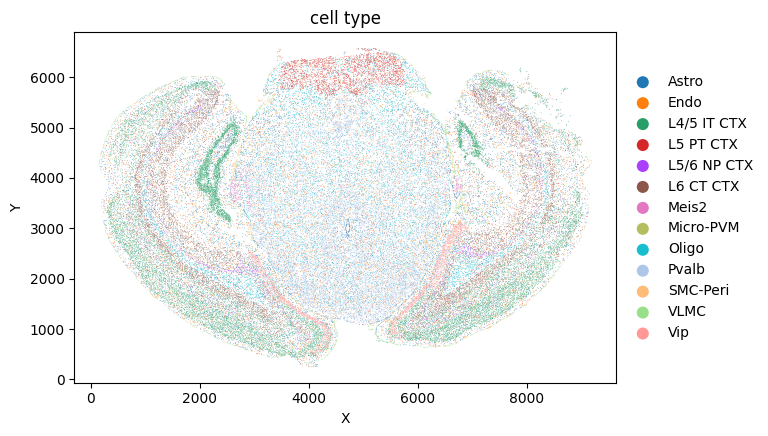

In [5]:
sc.pl.scatter(adata, x="X", y="Y", color="cell_type", size=1)


In [6]:
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)

In [7]:
df_ligrec = ct.pp.ligand_receptor_database(species="mouse",
                                           signaling_type="Secreted Signaling",
                                           database="CellChat")
df_cellchat_filtered = ct.pp.filter_lr_database(df_ligrec, adata, min_cell_pct=0.05)
df_cellchat_filtered

,0,1,2,3
0,Cxcl12,Cxcr4,CXCL,Secreted Signaling
1,Cxcl12,Ackr3,CXCL,Secreted Signaling
2,Cx3cl1,Cx3cr1,CX3C,Secreted Signaling


In [8]:
df_ligrec.columns = ['Ligand', 'Receptor', 'Pathway', 'Signaling_type']


In [9]:
db_genes = set(df_ligrec['Ligand']).union(df_ligrec['Receptor'])
overlap = db_genes.intersection(set(adata.var_names))

print(f"Genes in database: {len(db_genes)}")
print(f"Genes in dataset: {adata.n_vars}")
print(f"Overlap: {len(overlap)}")
print(list(overlap)[:20])  # show first 20 overlapping genes


Genes in database: 723
Genes in dataset: 649
Overlap: 148
['Ccr9', 'Sstr5', 'Calcrl', 'Sctr', 'Agtr1b', 'Tacr3', 'Gcgr', 'C3ar1', 'Rxfp2', 'Csf1r', 'Fshr', 'Ccr2', 'Fzd6', 'Cxcr4', 'Crhr2', 'Oprm1', 'Tek', 'Gpr83', 'Nmbr', 'Flt1']


In [14]:
import numpy as np

# Make sure coordinates are numeric
adata.obs['X'] = adata.obs['X'].astype(float)
adata.obs['Y'] = adata.obs['Y'].astype(float)

# Put into .obsm['spatial']
adata.obsm['spatial'] = np.vstack([adata.obs['X'], adata.obs['Y']]).T


In [ ]:
ct.tl.spatial_communication(adata,
    database_name='cellchat',
    df_ligrec=df_cellchat_filtered,
    dis_thr=500,
    heteromeric=True,
    pathway_sum=True)

In [3]:
adata_S1R1 = sc.read_h5ad("/home/akram/share/Result/COMMOT_S1R1/adata_spatial_communication_Full.h5ad")

In [4]:
print(adata_S1R1)

AnnData object with n_obs × n_vars = 67624 × 649
    obs: 'X', 'Y', 'cell_type'
    uns: 'cell_type_colors', 'commot-cellchat-info', 'log1p'
    obsm: 'commot-cellchat-sum-receiver', 'commot-cellchat-sum-sender', 'spatial'
    obsp: 'commot-cellchat-CX3C', 'commot-cellchat-CXCL', 'commot-cellchat-Cx3cl1-Cx3cr1', 'commot-cellchat-Cxcl12-Ackr3', 'commot-cellchat-Cxcl12-Cxcr4', 'commot-cellchat-total-total'


In [8]:
sender_labels_second = adata_S1R1.obs['cell_type']
receiver_labels_second = adata_S1R1.obs['cell_type']

In [ ]:
lr_names = [key for key in adata_S1R1.obsp.keys() if key.startswith('commot-cellchat')]

all_summaries = []

for lr_name in lr_names:
    lr_matrix = adata_S1R1.obsp[lr_name]
    lr_df = pd.DataFrame(lr_matrix.toarray(), index=sender_labels_second, columns=receiver_labels_second)
    summary = lr_df.groupby(level=0).sum().groupby(axis=1, level=0).sum()
    
    # Add a column or index to identify the LR pair
    summary['LR_pair'] = lr_name.replace('commot-cellchat-', '').replace('-', '_')
    
    # Convert to long format for easier concatenation
    summary_long = summary.reset_index().melt(id_vars=['cell_type', 'LR_pair'], var_name='receiver_cell_type', value_name='interaction_strength')
    
    all_summaries.append(summary_long)

# Concatenate all results
final_df = pd.concat(all_summaries, ignore_index=True)

# Save to one CSV
final_df.to_csv('all_lr_interactions_summary_full.csv', index=False)

print("All ligand-receptor summaries saved to all_lr_interactions_summary.csv")


All ligand-receptor summaries saved to all_lr_interactions_summary.csv


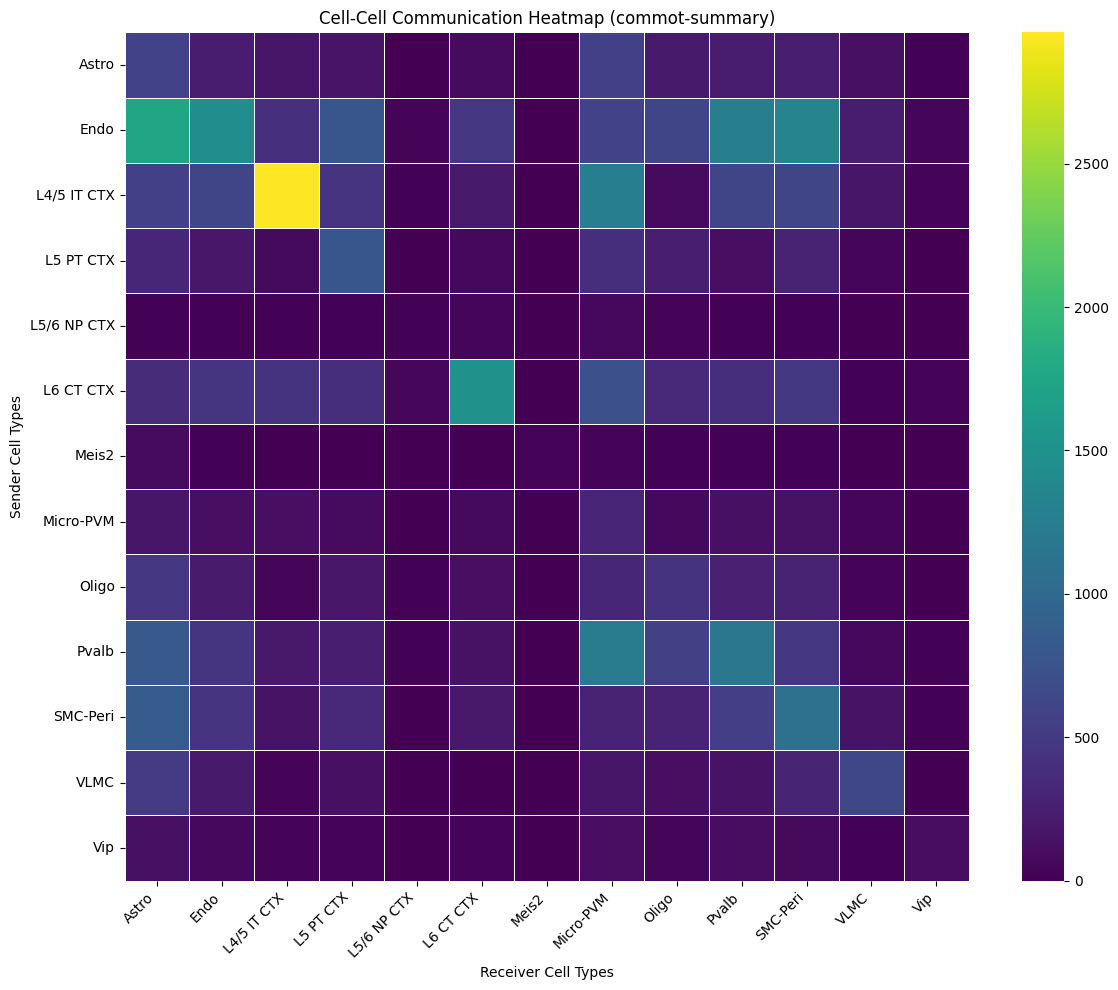

In [ ]:
# Extract the total-total matrix
total_total_matrix = adata_S1R1.obsp['commot-cellchat-total-total']

# Convert to DataFrame (make sure sender_labels and receiver_labels are defined)
total_total_df = pd.DataFrame(total_total_matrix.toarray(), index=sender_labels_second, columns=receiver_labels_second)

# Summarize by cell type (group by sender and receiver cell types)
summary = total_total_df.groupby(level=0).sum().groupby(axis=1, level=0).sum()

# Plot heatmap
plt.figure(figsize=(12,10))
sns.heatmap(summary, cmap='viridis', linewidths=0.5)
plt.title('Cell-Cell Communication Heatmap (commot-summary)')
plt.xlabel('Receiver Cell Types')
plt.ylabel('Sender Cell Types')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



### Save overall cell-type communication strength

In [9]:
total_total_matrix = adata_S1R1.obsp['commot-cellchat-total-total']
total_total_df = pd.DataFrame(
    total_total_matrix.toarray(),
    index=sender_labels_second,
    columns=receiver_labels_secong
)

commot_mat = total_total_df.groupby(level=0).sum().groupby(axis=1, level=0).sum()

commot_mat.to_csv("/home/akram/share/Result/COMMOT_S1R1/COMMOT_celltype_matrix.csv")
print("Saved: COMMOT_celltype_matrix.csv")
print(commot_mat.head())

Saved: COMMOT_celltype_matrix.csv
cell_type          Astro         Endo  L4/5 IT CTX   L5 PT CTX  L5/6 NP CTX  \
cell_type                                                                     
Astro         579.293063   226.209356   164.517205  158.864678     7.991132   
Endo         1739.153612  1445.622102   407.985883  787.646165    24.495594   
L4/5 IT CTX   559.643597   609.237874  2958.018864  448.392856    19.191481   
L5 PT CTX     318.282983   180.523563    78.736083  792.569437     4.389304   
L5/6 NP CTX    21.078279    17.166955    15.189120   13.932586    22.926448   

cell_type     L6 CT CTX      Meis2    Micro-PVM       Oligo        Pvalb  \
cell_type                                                                  
Astro         84.834600   6.861719   556.481003  207.216006   228.244715   
Endo         466.847030  10.776614   583.604901  603.733676  1264.889685   
L4/5 IT CTX  200.993298   2.007467  1251.247573   81.151240   600.875980   
L5 PT CTX     64.455326   1.6193